# FE

In [68]:
import numpy as np
import matplotlib.pyplot as plt

In [69]:
def eucl_dist(p1, p2):
    x1, z1 = p1
    x2, z2 = p2
    return np.sqrt((x2-x1)**2 + (z2-z1)**2)

def check_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)


class Node:

    def __init__(self, x: float, z: float, fixed=None):
        self.x = x
        self.z = z
        self.fixed = fixed if fixed is not None else [] # 0 -> local x fixed, 1 -> local z fixed, 2 -> theta fixed
        self.dofs = []
    
    def __str__(self) -> str:
        bcond = ""
        for i in self.fixed:
            match i:
                case 0:
                    bcond += "x "
                case 1:
                    bcond += "z "
                case 2:
                    bcond += "theta"
            

        return f"Node at x={self.x} and z={self.z} with fixed {bcond}" 


class Element:

    def __init__(self, n1, n2, E, I, A):
        self.n1 = n1
        self.n2 = n2
        self.E = E
        self.I = I
        self.A = A
        self.L = eucl_dist([n1.x, n1.z], [n2.x, n2.z]) # calc length
        self.psi = np.atan2(self.n2.z-self.n1.z, self.n2.x-self.n1.x) # calc angle

        Tgs = np.array([[np.cos(self.psi), np.sin(self.psi), 0], [-np.sin(self.psi), np.cos(self.psi), 0], [0, 0, 1]])

        self.Tg = np.zeros((6, 6))# global transformation mat
        self.Tg[0:3, 0:3] = Tgs
        self.Tg[3:6, 3:6] = Tgs

        k_loc = self.get_k_local()
        self.k_gl = self.Tg.T @ k_loc @ self.Tg
    
    def get_k_local(self) -> np.array:
        L, A, I, E = self.L, self.A, self.I, self.E
        mu = A*L**2/I
        k_loc = E * I / L**3 * np.array([
            [mu,  0,       0,      -mu,  0,       0     ],
            [0,   12,      6*L,     0,  -12,      6*L   ],
            [0,   6*L,     4*L**2,  0,  -6*L,     2*L**2],
            [-mu, 0,       0,       mu,  0,       0     ],
            [0,  -12,     -6*L,     0,   12,     -6*L   ],
            [0,   6*L,     2*L**2,  0,  -6*L,     4*L**2]
        ])
        
        return k_loc
    
    def __str__(self):
        return f"Element with L={self.L}, E={self.E}, I={self.I} and A={self.A} and Nodes:\n\t{self.n1.__str__()}\n\t{self.n2.__str__()}\nangle={self.psi}\n"


class NodalLoad:

    def __init__(self, node: Node, Fx=0, Fz=0, M=0):
        self.node = node
        self.Fx = Fx
        self.Fz = Fz
        self.M = M


class DistributedLoad:

    def __init__(self, element: Element, qz=0):
        # qz is the uniform load perpendicular to the local element axis (e.g., N/m)
        self.element = element
        self.qz = qz
        
    def get_equivalent_nodal_forces(self) -> np.array:
        L = self.element.L
        q = self.qz
        

        R_loc = np.array([
            0,             # local x1
            q * L / 2,     # local z1
            q * L**2 / 12, # local theta1
            0,             # local x2
            q * L / 2,     # local z2
            -q * L**2 / 12 # local theta2
        ])
        
        # transform local forces to global 
        R_glob = self.element.Tg.T @ R_loc
        return R_glob


class System:

    def __init__(self, elements:list, loads:list=None):
        self.elements = elements
        self.loads = loads if loads is not None else []
        self.nodes = []

        # find unique nodes
        for el in elements:
            for candidate in (el.n1, el.n2):
                # only add candidate if not close to existing node
                if candidate not in self.nodes:
                    self.nodes.append(candidate)
        
        for idx, node in enumerate(self.nodes):
            node.dofs = [0+idx*3, 1+idx*3, 2+idx*3]
        
    
    def assemble(self):
        total_dofs = 3*len(self.nodes)

        # initn displacement vec
        self.r = np.zeros(total_dofs)

        # stiffness mat
        K_glob = np.zeros((total_dofs, total_dofs))

        for el in self.elements:
            dofs = el.n1.dofs + el.n2.dofs
            K_glob[np.ix_(dofs, dofs)] += el.k_gl
            
        self.K_glob = K_glob
        
        # force vec
        self.R_glob = np.zeros(total_dofs)

        for load in self.loads:
            if isinstance(load, NodalLoad):
                dofs = load.node.dofs
                self.R_glob[dofs[0]] += load.Fx
                self.R_glob[dofs[1]] += load.Fz
                self.R_glob[dofs[2]] += load.M

            elif isinstance(load, DistributedLoad):
                R_eq = load.get_equivalent_nodal_forces()
                dofs = load.element.n1.dofs + load.element.n2.dofs
                self.R_glob[dofs] += R_eq



    def apply_bcs(self):
        fixed_dofs = []
        for node in self.nodes:
            for fixed_idx in node.fixed:
                fixed_dofs.append(node.dofs[fixed_idx])
        
        self.K_solve = np.copy(self.K_glob)
        for dof in fixed_dofs:
            self.K_solve[dof, :] = 0.0  # zero in row
            self.K_solve[:, dof] = 0.0  # zero in column
            self.K_solve[dof, dof] = 1.0  # set diag to 1
            
            # 3. Force the known displacement (0) in the load vector
            self.R_glob[dof] = 0.0 
            
        return self.K_glob, self.R_glob
    
    def solve(self):
        self.r = np.linalg.solve(self.K_solve, self.R_glob)
        return self.r
    
    def plot(self, scale=1.0, num_points=20):
        import matplotlib.pyplot as plt
        import numpy as np
        
        fig, ax = plt.subplots()
        
        for el in self.elements:
            # original nodal coordinates
            x1, z1 = el.n1.x, el.n1.z
            x2, z2 = el.n2.x, el.n2.z
            
            # plot undeformed state (dashed gray)
            ax.plot([x1, x2], [z1, z2], 'k--', alpha=0.5)
            
            if hasattr(self, 'r') and self.r is not None:
                # get global displacement
                r_global = np.array([
                    self.r[el.n1.dofs[0]], self.r[el.n1.dofs[1]], self.r[el.n1.dofs[2]],
                    self.r[el.n2.dofs[0]], self.r[el.n2.dofs[1]], self.r[el.n2.dofs[2]]
                ]) * scale
                
                # transform global disp to local element coord system
                r_local = el.Tg @ r_global
                u1, w1, theta1, u2, w2, theta2 = r_local
                
                # create interpolation points along local beam axis
                x_loc = np.linspace(0, el.L, num_points)
                xi = x_loc / el.L
                
                # lerp for axial displacement (u)
                u_x = u1 + (u2 - u1) * xi
                
                # cubic hermite shape functions for transverse displacement (w)
                N1 = 1 - 3*xi**2 + 2*xi**3
                N2 = x_loc * (1 - xi)**2
                N3 = 3*xi**2 - 2*xi**3
                N4 = x_loc * (xi**2 - xi)
                
                w_x = N1*w1 + N2*theta1 + N3*w2 + N4*theta2
                
                # calculate displaced local coordinates
                x_def_loc = x_loc + u_x
                z_def_loc = w_x
                
                # transform deformed local coordinates back to global space
                c, s = np.cos(el.psi), np.sin(el.psi)
                x_def_glob = x1 + x_def_loc * c - z_def_loc * s
                z_def_glob = z1 + x_def_loc * s + z_def_loc * c
                
                # plot deformed curve
                ax.plot(x_def_glob, z_def_glob, 'r-')
                
        ax.set_aspect('equal', adjustable='box')
        plt.xlabel('X')
        plt.ylabel('Z')
        plt.title(f'Deformation Plot (Scale: {scale}x)')
        plt.show()

    
    def __str__(self):
        elstr = ""
        for el in self.elements:
            elstr += el.__str__()

        return f"System containing {len(self.elements)} elements:\n{elstr}"


[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  4.18836342e-07
 -1.77886205e-07  1.35288507e-04 -4.18836342e-07  0.00000000e+00
 -4.14931571e-04  0.00000000e+00  0.00000000e+00  0.00000000e+00]


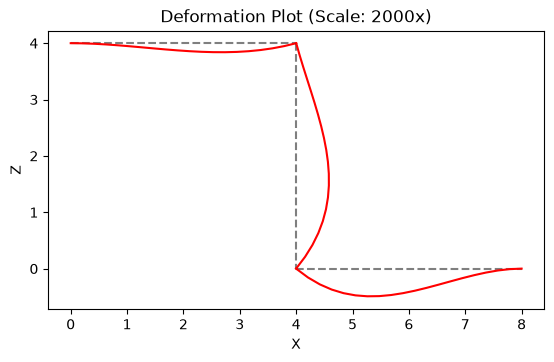

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.25393750e+09
  -3.21228682e-07  7.87500000e+06 -3.93750000e+06  0.00000000e+00
   7.87500000e+06  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.21228682e-07
   5.25393750e+09 -7.87500000e+06  3.21228682e-07  0.00000000e+00
   4.82204677e-10  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.

In [71]:
E = 210e9 # Pa
I = 10e-5 # m⁴
A = 10e-2 # m2

q = 1000 # N/m

n1 = Node(0, 4, fixed=[0, 1, 2])
n2 = Node(4, 4)
n3 = Node(4, 0, fixed=[1])
n4 = Node(8, 0, fixed=[0, 1, 2])

e1 = Element(n1, n2, E, I, A)
e2 = Element(n2, n3, E, I, A)
e3 = Element(n3, n4, E, I, A)

nl3 = NodalLoad(n3, 0, 0, -q*e1.L**2)
dl1 = DistributedLoad(e1, -q)

sys = System([e1, e2, e3], [nl3, dl1])
sys.assemble()
sys.apply_bcs()

r = sys.solve()
print(r)

sys.plot(scale=2000)
print(sys.K_solve)